# Notebook 05 — EfficientNet + Transfer Learning

## Objectif
Utiliser EfficientNet-B0 pré-entraîné sur ImageNet via Transfer Learning.
Au lieu de partir de zéro comme le CNN scratch, on réutilise un modèle 
qui a déjà appris sur 1,2 million d'images.

## Pourquoi EfficientNet-B0
- ResNet50 : 23 millions de paramètres → trop grand pour 779 images
- EfficientNet-B0 : 5 millions de paramètres → adapté à notre dataset

## Deux versions
1. EfficientNet + Cross-Entropy classique
2. EfficientNet + Loss Ordinale (notre originalité)

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : cpu


In [32]:
# Classe Dataset
class AcneDataset(Dataset):
    def __init__(self, csv_path, images_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.images_path = images_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        nom_image = self.df.iloc[idx]["image"]
        niveau = self.df.iloc[idx]["niveau"]
        chemin = os.path.join(self.images_path, nom_image)
        image = Image.open(chemin).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, niveau

# Chemins
IMAGES_PATH = "../data/images_preprocessees"
TRAIN_CSV = "../data/splits/train.csv"
VAL_CSV = "../data/splits/val.csv"
TEST_CSV = "../data/splits/test.csv"

# Transforms
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# DataLoaders
train_loader = DataLoader(AcneDataset(TRAIN_CSV, IMAGES_PATH, transform_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(AcneDataset(VAL_CSV, IMAGES_PATH, transform_val_test), batch_size=32, shuffle=False)
test_loader  = DataLoader(AcneDataset(TEST_CSV, IMAGES_PATH, transform_val_test), batch_size=32, shuffle=False)

print(f"Train : {len(train_loader.dataset)} images")
print(f"Val   : {len(val_loader.dataset)} images")
print(f"Test  : {len(test_loader.dataset)} images")

Train : 975 images
Val   : 209 images
Test  : 210 images


In [33]:
# Charger EfficientNet-B0 pré-entraîné
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

modele_efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Geler toutes les couches sauf la dernière
for param in modele_efficientnet.parameters():
    param.requires_grad = False

# Remplacer la dernière couche par 4 neurones (nos 4 niveaux)
modele_efficientnet.classifier[1] = nn.Linear(
    modele_efficientnet.classifier[1].in_features, 4
)

# Envoyer sur le device
modele_efficientnet = modele_efficientnet.to(device)

print("EfficientNet-B0 chargé ✓")
print(f"Nombre de paramètres entraînables : {sum(p.numel() for p in modele_efficientnet.parameters() if p.requires_grad):,}")

EfficientNet-B0 chargé ✓
Nombre de paramètres entraînables : 5,124


In [34]:
# Loss et optimiseur
criterion = nn.CrossEntropyLoss()
optimiseur = optim.Adam(modele_efficientnet.parameters(), lr=0.001)

# Boucle d'entraînement
def entrainer(modele, train_loader, val_loader, criterion, optimiseur, nb_epoques=20):
    historique = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoque in range(nb_epoques):
        
        # TRAIN
        modele.train()
        train_loss, train_correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimiseur.zero_grad()
            sorties = modele(images)
            loss = criterion(sorties, labels)
            loss.backward()
            optimiseur.step()
            train_loss += loss.item()
            train_correct += (sorties.argmax(1) == labels).sum().item()
        
        # VALIDATION
        modele.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                sorties = modele(images)
                loss = criterion(sorties, labels)
                val_loss += loss.item()
                val_correct += (sorties.argmax(1) == labels).sum().item()
        
        train_acc = train_correct / len(train_loader.dataset)
        val_acc   = val_correct / len(val_loader.dataset)
        train_loss = train_loss / len(train_loader)
        val_loss   = val_loss / len(val_loader)
        
        historique["train_loss"].append(train_loss)
        historique["val_loss"].append(val_loss)
        historique["train_acc"].append(train_acc)
        historique["val_acc"].append(val_acc)
        
        print(f"Époque {epoque+1}/{nb_epoques} | "
              f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.3f}")
    
    return historique

historique_efficientnet = entrainer(
    modele_efficientnet, train_loader, val_loader, 
    criterion, optimiseur, nb_epoques=20
)

Époque 1/20 | Train Loss: 1.127 | Train Acc: 0.466 | Val Loss: 1.084 | Val Acc: 0.459
Époque 2/20 | Train Loss: 1.014 | Train Acc: 0.536 | Val Loss: 1.045 | Val Acc: 0.440
Époque 3/20 | Train Loss: 0.950 | Train Acc: 0.542 | Val Loss: 1.021 | Val Acc: 0.474
Époque 4/20 | Train Loss: 0.922 | Train Acc: 0.595 | Val Loss: 0.998 | Val Acc: 0.493
Époque 5/20 | Train Loss: 0.894 | Train Acc: 0.598 | Val Loss: 0.982 | Val Acc: 0.512
Époque 6/20 | Train Loss: 0.859 | Train Acc: 0.637 | Val Loss: 0.978 | Val Acc: 0.517
Époque 7/20 | Train Loss: 0.862 | Train Acc: 0.600 | Val Loss: 0.954 | Val Acc: 0.541
Époque 8/20 | Train Loss: 0.835 | Train Acc: 0.625 | Val Loss: 0.946 | Val Acc: 0.536
Époque 9/20 | Train Loss: 0.825 | Train Acc: 0.632 | Val Loss: 0.947 | Val Acc: 0.526
Époque 10/20 | Train Loss: 0.806 | Train Acc: 0.649 | Val Loss: 0.938 | Val Acc: 0.569
Époque 11/20 | Train Loss: 0.795 | Train Acc: 0.661 | Val Loss: 0.932 | Val Acc: 0.541
Époque 12/20 | Train Loss: 0.792 | Train Acc: 0.651 

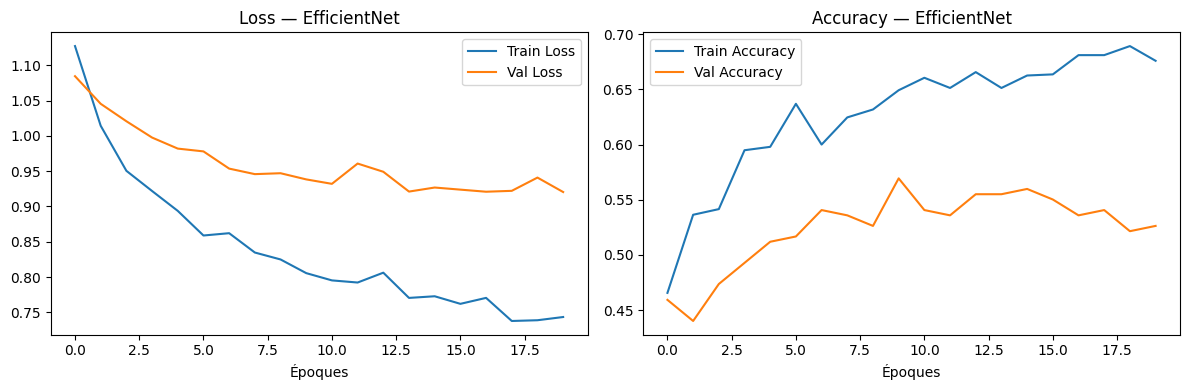

=== EfficientNet + Cross-Entropy — Résultats finaux ===
Accuracy : 0.648
F1-Score : 0.570


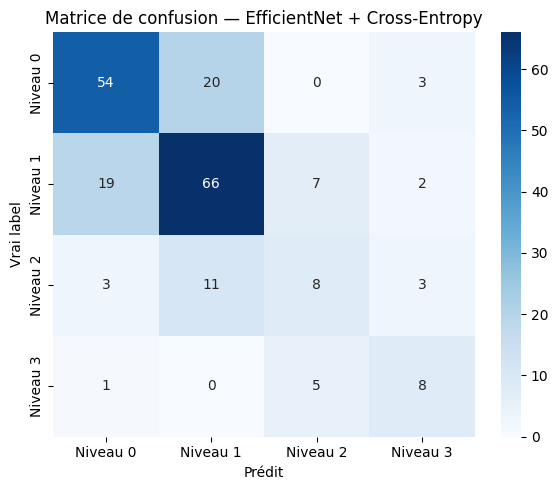

In [52]:
# Courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historique_efficientnet["train_loss"], label="Train Loss")
ax1.plot(historique_efficientnet["val_loss"], label="Val Loss")
ax1.set_title("Loss — EfficientNet")
ax1.set_xlabel("Époques")
ax1.legend()

ax2.plot(historique_efficientnet["train_acc"], label="Train Accuracy")
ax2.plot(historique_efficientnet["val_acc"], label="Val Accuracy")
ax2.set_title("Accuracy — EfficientNet")
ax2.set_xlabel("Époques")
ax2.legend()

plt.tight_layout()
plt.show()

# Evaluation sur le test set
modele_efficientnet.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        sorties = modele_efficientnet(images)
        predictions = sorties.argmax(1).cpu().numpy()
        y_pred.extend(predictions)
        y_true.extend(labels.numpy())

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print(f"=== EfficientNet + Cross-Entropy — Résultats finaux ===")
print(f"Accuracy : {acc:.3f}")
print(f"F1-Score : {f1:.3f}")

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Niveau 0", "Niveau 1", "Niveau 2", "Niveau 3"],
            yticklabels=["Niveau 0", "Niveau 1", "Niveau 2", "Niveau 3"])
plt.title("Matrice de confusion — EfficientNet + Cross-Entropy")
plt.ylabel("Vrai label")
plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig("../results/figures/matrice_efficientnet_ce.png", dpi=150, bbox_inches='tight')

plt.show()

In [36]:
def loss_ord_finale(sorties, labels):
    batch_size = labels.size(0)
    cibles = torch.zeros(batch_size, 3).to(labels.device)
    for i in range(batch_size):
        niveau = labels[i].item()
        for k in range(niveau):
            cibles[i, k] = 1.0
    pred = torch.sigmoid(sorties)
    erreur = -(cibles * torch.log(pred) + (1 - cibles) * torch.log(1 - pred))
    return erreur.mean()

print("loss_ord_finale définie ✓")

loss_ord_finale définie ✓


In [37]:
eff_ord = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

for param in eff_ord.parameters():
    param.requires_grad = False

eff_ord.classifier[1] = nn.Linear(eff_ord.classifier[1].in_features, 3)
eff_ord = eff_ord.to(device)
opt_ord = optim.Adam(eff_ord.classifier.parameters(), lr=0.001)

print(f"Paramètres entraînables : {sum(p.numel() for p in eff_ord.parameters() if p.requires_grad):,}")

Paramètres entraînables : 3,843


# Entraînement EfficientNet + Loss Ordinale

L'entraînement a été fait en 3 phases :
- Époques 1-20 : première phase
- Époques 20-40 : deuxième phase
- Époques 40-70 : troisième phase avec sauvegarde du meilleur modèle
Le meilleur modèle (époque 48, val acc = 61.7%) est sauvegardé dans results/models/eff_ord_best.pth

In [38]:
for epoque in range(20):
    eff_ord.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        opt_ord.zero_grad()
        sorties = eff_ord(images)
        loss = loss_ord_finale(sorties, labels)
        loss.backward()
        opt_ord.step()
        train_loss += loss.item()
        predictions = (torch.sigmoid(sorties) > 0.5).sum(dim=1)
        train_correct += (predictions == labels).sum().item()
    
    eff_ord.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            sorties = eff_ord(images)
            loss = loss_ord_finale(sorties, labels)
            val_loss += loss.item()
            predictions = (torch.sigmoid(sorties) > 0.5).sum(dim=1)
            val_correct += (predictions == labels).sum().item()
    
    train_acc = train_correct / len(train_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)
    print(f"Époque {epoque+1}/20 | "
          f"Train Loss: {train_loss/len(train_loader):.3f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss/len(val_loader):.3f} | Val Acc: {val_acc:.3f}")

Époque 1/20 | Train Loss: 0.466 | Train Acc: 0.441 | Val Loss: 0.425 | Val Acc: 0.435
Époque 2/20 | Train Loss: 0.399 | Train Acc: 0.486 | Val Loss: 0.400 | Val Acc: 0.531
Époque 3/20 | Train Loss: 0.381 | Train Acc: 0.525 | Val Loss: 0.387 | Val Acc: 0.488
Époque 4/20 | Train Loss: 0.367 | Train Acc: 0.538 | Val Loss: 0.372 | Val Acc: 0.488
Époque 5/20 | Train Loss: 0.344 | Train Acc: 0.573 | Val Loss: 0.363 | Val Acc: 0.493
Époque 6/20 | Train Loss: 0.338 | Train Acc: 0.570 | Val Loss: 0.355 | Val Acc: 0.512
Époque 7/20 | Train Loss: 0.340 | Train Acc: 0.563 | Val Loss: 0.353 | Val Acc: 0.512
Époque 8/20 | Train Loss: 0.327 | Train Acc: 0.598 | Val Loss: 0.347 | Val Acc: 0.574
Époque 9/20 | Train Loss: 0.323 | Train Acc: 0.598 | Val Loss: 0.341 | Val Acc: 0.565
Époque 10/20 | Train Loss: 0.314 | Train Acc: 0.622 | Val Loss: 0.342 | Val Acc: 0.512
Époque 11/20 | Train Loss: 0.321 | Train Acc: 0.594 | Val Loss: 0.338 | Val Acc: 0.545
Époque 12/20 | Train Loss: 0.305 | Train Acc: 0.624 

In [39]:
for epoque in range(20, 40):
    eff_ord.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        opt_ord.zero_grad()
        sorties = eff_ord(images)
        loss = loss_ord_finale(sorties, labels)
        loss.backward()
        opt_ord.step()
        train_loss += loss.item()
        predictions = (torch.sigmoid(sorties) > 0.5).sum(dim=1)
        train_correct += (predictions == labels).sum().item()
    
    eff_ord.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            sorties = eff_ord(images)
            loss = loss_ord_finale(sorties, labels)
            val_loss += loss.item()
            predictions = (torch.sigmoid(sorties) > 0.5).sum(dim=1)
            val_correct += (predictions == labels).sum().item()
    
    train_acc = train_correct / len(train_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)
    print(f"Époque {epoque+1}/40 | "
          f"Train Loss: {train_loss/len(train_loader):.3f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss/len(val_loader):.3f} | Val Acc: {val_acc:.3f}")

Époque 21/40 | Train Loss: 0.282 | Train Acc: 0.657 | Val Loss: 0.321 | Val Acc: 0.598
Époque 22/40 | Train Loss: 0.289 | Train Acc: 0.629 | Val Loss: 0.319 | Val Acc: 0.584
Époque 23/40 | Train Loss: 0.286 | Train Acc: 0.665 | Val Loss: 0.319 | Val Acc: 0.598
Époque 24/40 | Train Loss: 0.274 | Train Acc: 0.678 | Val Loss: 0.318 | Val Acc: 0.574
Époque 25/40 | Train Loss: 0.283 | Train Acc: 0.646 | Val Loss: 0.318 | Val Acc: 0.584
Époque 26/40 | Train Loss: 0.272 | Train Acc: 0.678 | Val Loss: 0.319 | Val Acc: 0.579
Époque 27/40 | Train Loss: 0.272 | Train Acc: 0.664 | Val Loss: 0.316 | Val Acc: 0.574
Époque 28/40 | Train Loss: 0.266 | Train Acc: 0.666 | Val Loss: 0.315 | Val Acc: 0.589
Époque 29/40 | Train Loss: 0.271 | Train Acc: 0.682 | Val Loss: 0.320 | Val Acc: 0.603
Époque 30/40 | Train Loss: 0.270 | Train Acc: 0.646 | Val Loss: 0.314 | Val Acc: 0.598
Époque 31/40 | Train Loss: 0.274 | Train Acc: 0.651 | Val Loss: 0.315 | Val Acc: 0.603
Époque 32/40 | Train Loss: 0.269 | Train Ac

In [44]:
meilleure_val_acc = 0

for epoque in range(40, 70):
    eff_ord.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        opt_ord.zero_grad()
        sorties = eff_ord(images)
        loss = loss_ord_finale(sorties, labels)
        loss.backward()
        opt_ord.step()
        train_loss += loss.item()
        predictions = (torch.sigmoid(sorties) > 0.5).sum(dim=1)
        train_correct += (predictions == labels).sum().item()

    eff_ord.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            sorties = eff_ord(images)
            loss = loss_ord_finale(sorties, labels)
            val_loss += loss.item()
            predictions = (torch.sigmoid(sorties) > 0.5).sum(dim=1)
            val_correct += (predictions == labels).sum().item()

    train_acc = train_correct / len(train_loader.dataset)
    val_acc   = val_correct   / len(val_loader.dataset)

    # Sauvegarder le meilleur
    if val_acc > meilleure_val_acc:
        meilleure_val_acc = val_acc
        torch.save(eff_ord.state_dict(), "../results/models/eff_ord_best.pth")
        print(f"  ✓ Sauvegardé — époque {epoque+1} | Val Acc: {val_acc:.3f}")

    print(f"Époque {epoque+1}/70 | "
          f"Train Loss: {train_loss/len(train_loader):.3f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss/len(val_loader):.3f} | Val Acc: {val_acc:.3f}")

print(f"\nMeilleure Val Accuracy : {meilleure_val_acc:.3f}")

  ✓ Sauvegardé — époque 41 | Val Acc: 0.579
Époque 41/70 | Train Loss: 0.257 | Train Acc: 0.695 | Val Loss: 0.318 | Val Acc: 0.579
  ✓ Sauvegardé — époque 42 | Val Acc: 0.589
Époque 42/70 | Train Loss: 0.258 | Train Acc: 0.680 | Val Loss: 0.309 | Val Acc: 0.589
  ✓ Sauvegardé — époque 43 | Val Acc: 0.598
Époque 43/70 | Train Loss: 0.258 | Train Acc: 0.683 | Val Loss: 0.307 | Val Acc: 0.598
Époque 44/70 | Train Loss: 0.264 | Train Acc: 0.658 | Val Loss: 0.322 | Val Acc: 0.565
Époque 45/70 | Train Loss: 0.261 | Train Acc: 0.676 | Val Loss: 0.307 | Val Acc: 0.589
Époque 46/70 | Train Loss: 0.247 | Train Acc: 0.691 | Val Loss: 0.309 | Val Acc: 0.569
Époque 47/70 | Train Loss: 0.254 | Train Acc: 0.678 | Val Loss: 0.305 | Val Acc: 0.589
  ✓ Sauvegardé — époque 48 | Val Acc: 0.617
Époque 48/70 | Train Loss: 0.262 | Train Acc: 0.678 | Val Loss: 0.306 | Val Acc: 0.617
Époque 49/70 | Train Loss: 0.255 | Train Acc: 0.694 | Val Loss: 0.309 | Val Acc: 0.598
Époque 50/70 | Train Loss: 0.252 | Train 

KeyboardInterrupt: 

In [46]:
# Charger le meilleur modèle et évaluer
eff_ord.load_state_dict(torch.load("../results/models/eff_ord_best.pth"))

eff_ord.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        sorties = eff_ord(images)
        predictions = (torch.sigmoid(sorties) > 0.5).sum(dim=1)
        y_pred.extend(predictions.cpu().numpy())
        y_true.extend(labels.numpy())

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average="macro")

print(f"=== EfficientNet + Loss Ordinale — Meilleur modèle ===")
print(f"Accuracy : {acc:.3f}")
print(f"F1-Score : {f1:.3f}")

=== EfficientNet + Loss Ordinale — Meilleur modèle ===
Accuracy : 0.610
F1-Score : 0.526


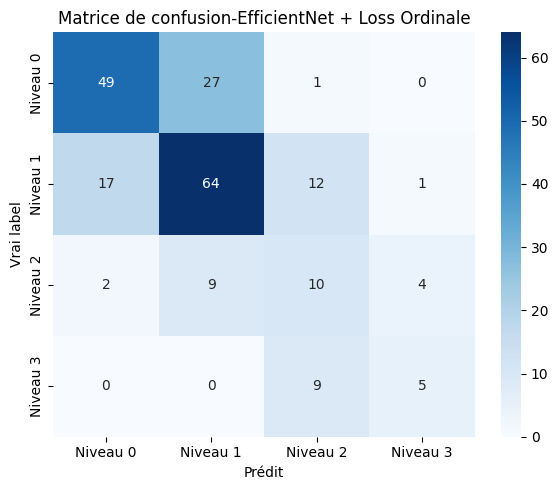

In [51]:
# Matrice de confusion — EfficientNet + Loss Ordinale
cm_ord = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ord, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Niveau 0", "Niveau 1", "Niveau 2", "Niveau 3"],
            yticklabels=["Niveau 0", "Niveau 1", "Niveau 2", "Niveau 3"])
plt.title("Matrice de confusion-EfficientNet + Loss Ordinale")
plt.ylabel("Vrai label")
plt.xlabel("Prédit")
plt.tight_layout()
plt.savefig("../results/figures/matrice_efficientnet_ord.png", dpi=150, bbox_inches='tight')
plt.show()

In [48]:
print("=" * 58)
print(f"{'Modèle':<35} {'Accuracy':>8} {'F1-Score':>8}")
print("=" * 58)
print(f"{'KNN (baseline ML)':<35} {0.448:>8.3f} {0.308:>8.3f}")
print(f"{'CNN Scratch':<35} {0.481:>8.3f} {0.344:>8.3f}")
print(f"{'EfficientNet + Cross-Entropy':<35} {0.648:>8.3f} {0.570:>8.3f}")
print(f"{'EfficientNet + Loss Ordinale':<35} {0.610:>8.3f} {0.526:>8.3f}")
print("=" * 58)

Modèle                              Accuracy F1-Score
KNN (baseline ML)                      0.448    0.308
CNN Scratch                            0.481    0.344
EfficientNet + Cross-Entropy           0.648    0.570
EfficientNet + Loss Ordinale           0.610    0.526


In [49]:
torch.save(modele_efficientnet.state_dict(), "../results/models/efficientnet_ce_best.pth")
print("Modèle Cross-Entropy sauvegardé ✓")

Modèle Cross-Entropy sauvegardé ✓


In [50]:
plt.savefig("../results/figures/matrice_efficientnet_ce.png", dpi=150, bbox_inches='tight')
plt.savefig("../results/figures/matrice_efficientnet_ord.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>